In [1]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')

    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)



    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)


def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):

    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]

    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)

    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')

    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])


    return X_train,y_train,X_val,y_val,X_test,y_test

In [2]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.16.2
3.13.2


In [3]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


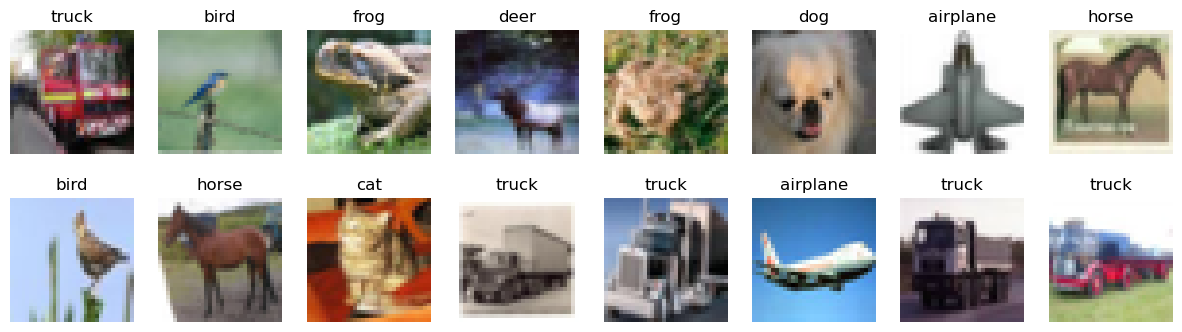

In [4]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

In [5]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
# x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [6]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from keras.layers import LeakyReLU

In [7]:
def make_model():
    """
    Define your model architecture here.
    Returns `Sequential` model.
    """

    model = Sequential()

    ### STUDENT CODE HERE ###
    ### --> Build your convolutional neural network.
    ### First, make a CNN layer with some small kernels to learn some basic features, with Conv2D.
    ### Then, add a Pooling layer to pick up the relevant kernels.
    ### Then, Flatten it and add some fully-connected (Dense) normal NN layers,
    ###  to learn the relevant combinations of low-level kernel features.
    ### Finally, some regularisation is advised, using a Dropout layer, to avoid local minima.
    ### Make sure the output is of the same shape as the number of labels we have,
    ### And the input is the same as the figures (which now have a 3rd dimension - color!)
    ### Again, use google to find information on these classes.

    # L2 weight decay I used throughout the network to prevent overfitting
    reg = keras.regularizers.l2(1e-4)

    model.add(keras.layers.Input(shape=x_train.shape[1:]))
    model.add(keras.layers.RandomFlip("horizontal")) # horizontal flips only
    model.add(keras.layers.RandomTranslation(0.1, 0.1)) # small spatial shifts
    model.add(keras.layers.RandomZoom(0.1)) # small scale variations

    # Block 1: low level features like edges and textures
    model.add(Conv2D(32, (3, 3), padding="same", kernel_regularizer=reg))
    model.add(keras.layers.BatchNormalization()) # stabilizes the activations
    model.add(Activation("relu")) # Better stability and computability for several layered models
    model.add(Conv2D(32, (3, 3), padding="same", kernel_regularizer=reg))
    model.add(keras.layers.BatchNormalization())
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2, 2))) # spatial downsampling 
    model.add(Dropout(0.05)) # a bit of final regularization

    # Block 2
    model.add(Conv2D(64, (3, 3), padding="same", kernel_regularizer=reg))
    model.add(keras.layers.BatchNormalization())
    model.add(Activation("relu"))
    model.add(Conv2D(64, (3, 3), padding="same", kernel_regularizer=reg))
    model.add(keras.layers.BatchNormalization())
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.10))

    # Block 3
    model.add(Conv2D(128, (3, 3), padding="same", kernel_regularizer=reg))
    model.add(keras.layers.BatchNormalization())
    model.add(Activation("relu"))
    model.add(Conv2D(128, (3, 3), padding="same", kernel_regularizer=reg))
    model.add(keras.layers.BatchNormalization())
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.15))

    # Block 4: high level features (magic or the power of friendship in pictures probably)
    model.add(Conv2D(256, (3, 3), padding="same", kernel_regularizer=reg))
    model.add(keras.layers.BatchNormalization())
    model.add(Activation("relu"))
    model.add(Conv2D(256, (3, 3), padding="same", kernel_regularizer=reg))
    model.add(keras.layers.BatchNormalization())
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.20))

    # GlobalAveragePooling reduces parameters compared to Flatten and forces each feature map to represent a meaningful global feature
    model.add(keras.layers.GlobalAveragePooling2D())

    # Final calssification head
    model.add(Dense(256, kernel_regularizer=reg))
    model.add(Activation("relu"))
    model.add(Dropout(0.25))
    model.add(Dense(NUM_CLASSES, kernel_regularizer=reg))

    ### END STUDENT CODE ###
    model.add(Activation("softmax"))

    return model

In [8]:
### STUDENT CODE HERE ###
### --> change the parameters below to perform a better training

INIT_LR = 1e-3  # initial relatively agressive learning rate
BATCH_SIZE = 64 # large badge improved training stability
EPOCHS =  200 # upper limit but usually stopped in the low 100s

# Callbacks to stabilize training and prevent unnecessary epochs
callbacks = [keras.callbacks.EarlyStopping( # This is to stop training if validation accuracy stops improving
        monitor="val_accuracy",
        mode="max",
        patience=12, # allow some epochs for recovery
        restore_best_weights=True, # keep best performing model
        ),

    # And this reduces the learning rate when validation accuracy plateaus
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy", # accuracy proved more stable than val_loss
        mode="max",
        factor=0.5, # learnign rate goes down by half
        patience=6,
        min_lr=1e-5, # prevent learning rate from becoming too small
        verbose=1,
    ),
]



K.clear_session()  # clear default graph
# don't call K.set_learning_phase() !!! (otherwise will enable dropout in train/test simultaneously)
model = make_model()  # define our model

# prepare model for fitting (loss, optimizer, etc)
model.compile(
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1), # label smoothing slightly regularizes predictions and reduces overconfidence
    optimizer=keras.optimizers.Adam(learning_rate=INIT_LR), # Adam optimizer with tuned learning rate
    metrics=["accuracy"]
)

# fit model
history = model.fit(
    x_train, y_train,  # prepared data
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    shuffle=True,
    callbacks=callbacks,
)

# save weights to file to avoid re-training
model.save_weights("myweights.weights.h5")

Epoch 1/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.3820 - loss: 1.9586 - val_accuracy: 0.4592 - val_loss: 1.8657 - learning_rate: 0.0010
Epoch 2/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.5946 - loss: 1.5239 - val_accuracy: 0.6290 - val_loss: 1.4633 - learning_rate: 0.0010
Epoch 3/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.6729 - loss: 1.3708 - val_accuracy: 0.6001 - val_loss: 1.5466 - learning_rate: 0.0010
Epoch 4/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.7160 - loss: 1.2925 - val_accuracy: 0.6946 - val_loss: 1.3428 - learning_rate: 0.0010
Epoch 5/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.7397 - loss: 1.2466 - val_accuracy: 0.6500 - val_loss: 1.4275 - learning_rate: 0.0010
Epoch 6/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7565 - loss: 1.2130 - val_accuracy: 0.5970 - val_loss: 1.5876 - learning_rate: 0.0010
Epoch 7/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7

In [9]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


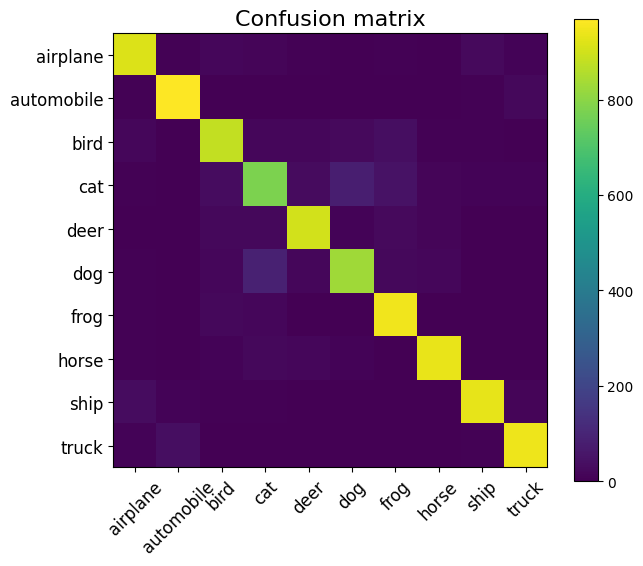

Test accuracy: 0.903


In [10]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

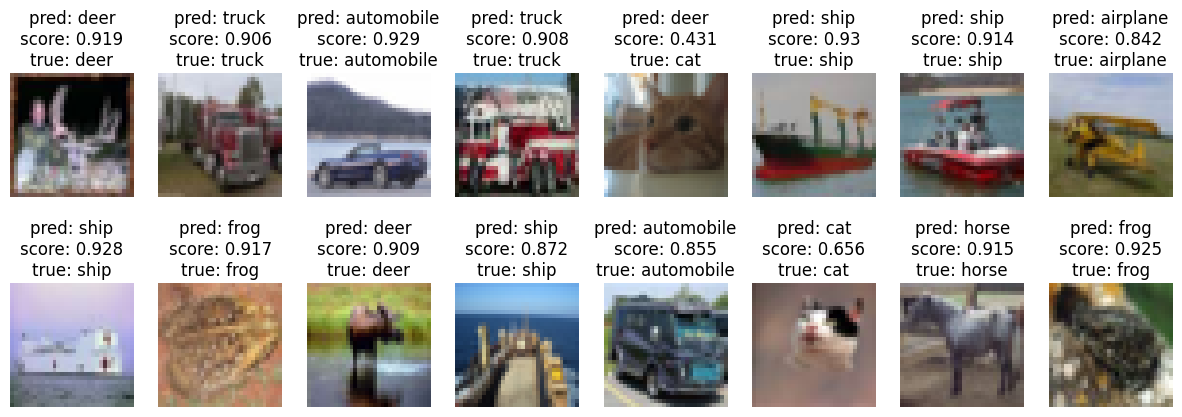

In [11]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons,
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ -
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.




# Convolutional Neural Network Design Report

I started my CNN with a simple one Conv2D layer of 32 filters with a 3×3 kernel, one pooling layer, a flattening step and a final Dense classifier layer following the first step instructions. This model of course was too simplistic and gave terrible accuracy results (planes and dogs were quite similar creatures in this model's opinion). 

After the first very underperforming attempt I followed the notebook's suggestions and added three Conv2D layers with 32, 64 and 128 filters which after not many iterations I added 256 and 512 layers as well, but I saw drops on the accuracy with the last layer so I just kept the 256 layer. I used ReLU instead of sigmoid for activation, since from what I could find in a quick Google search, ReLU is the standard one used for CNNs since sigmoid is much slower, computationally expensive (it uses an exponential function while ReLU just uses max) and in general not optimized for multiple layer models, as its gradient disappears quickly. I followed each layer by a BatchNormalization to stabilize it and make it less sensitive to the initial conditions, MaxPooling2D and Dropout (to prevent overfitting and over-reliance on specific weights). Then I finished the model by flattening the output of the CNN layers and passing it through a dense layer with 256 units to get the classes for the images. Using a batch size of 32 and five epochs this model reached an accuracy of about 0.409, so back to the drawing board I went.

The first major improvement was to replace flattening with GlobalAveragePooling2D, as I found in the Keras documentation, this drastically reduces the number of parameters. As it averages the 2×2 region for each one of the 256 channels, we end up with a vector with 256 parameters, in comparison with flattening which would have given 1024. As I understood it, this forces each channel to represent a feature and how strongly this feature is present in the image. And after that I just had a 256 Dense layer to get the image classes. This change boosted the accuracy to 0.5.

After playing around with some different values for the model like 48 $\to$ 96 $\to$ 192 filters I ended up realizing that the 32 $\to$ 64 $\to$ 128 architecture was best, as the other ones got as low as 0.2. Once I had this basic "best model architecture" I started changing the training parameters. Increasing epochs to 50, batch size to 64 and the initial learning rate to 1e-3. This very subtle change immediately pushed the accuracy to 0.76. After this sudden jump I started playing around with the training parameters, especially trying different initial learning rates and more epochs. I got up to 500 epochs (my computer was not a pretty sight) but it converged really quickly around 150 epochs. After this testing I added the suggested features for L2 weight decay and regularization with a kernel regularizer, with a regularization of l2(5e-4), EarlyStopping to keep the best weights even if the model started converging and finally, and I think one of the best additions, ReduceLROnPlateau so that we could start with very aggressive optimization and make it more precise in the later stages. I also changed the optimizer from Adamax to Adam (Chat GPT suggestion) since Adam converges faster and more predictably than Adamax for CNN and specifically on CIFAR-10. All of these changes pushed the model to an accuracy of 0.8.

The next minor but significant improvement was data augmentation flipping images only with RandomFlip("horizontal"), since it was unlikely to find upside-down objects in the dataset, and adding RandomZoom(0.1) and RandomTranslation(0.1, 0.1) so that the model didn't select for a specific arrangement or composition of the training images and instead focused more on the objects themselves. This finally pushed the model to 0.86 accuracy.

After that I could have called it a day. But I needed to get to 0.9 accuracy. So I started a very long journey of tweaking to get that remaining two percent which was probably the most difficult to obtain. Train accuracy and validation accuracy were reasonably close, so the model was probably slightly over-regularized. Therefore I reduced L2 from 5e-4 to 1e-4, lowered the dropout rates a little, since I was being a bit agressive starting from 0.1 to 0.4 but lowered it to small 0.05 increments ebtween layers, and finally I added label_smoothing=0.1 and changed ReduceLROnPlateau to monitor val_accuracy instead of val_loss, since val_loss could be noisy even when val_accuracy kept improving. It ended up taking only 88 epochs until the callback stopped it, although I set it up initially for 200 epochs just to be sure. This model reached 0.9 validation accuracy and 0.9 test accuracy. So after much trials and tribulations I got my incredible accuracy.